# U.S. Medical Insurance Costs
This project examines the medical expenses for people in relation to their sex, bmi, smoking status, age, number of children, region etc. The insurance costs is in a CSV file and Python fundamentals will be used to analyze the data. The initial part of the project was done before I learned the advanced concepts. I completed this project after learning advanced concepts in Python.

# These are the questions in my mind:
- Do men or women have higher insurance charges on an average?
- Does the insurance charge go up as the bmi?
- Is the insurance cost affected by smoker status?
- How does the age affect insurance cost?
- Does the bmi increase with age?
- How are the charges affected by regions?








In [4]:
#import csv library
import csv

We need to import the different columns in the csv file to a Python file. We can use a function to do this easily so we 
don't have to repeat the same steps for each column. First we save each column as an empty list


In [6]:
sexes = []
ages=[]
bmis = []
number_of_children = []
regions = []
smoker_statuses =[]
insurance_charges =[]

In [77]:

    #function to automatically fill the list for each attribute
    def auto_list(col, list,file):
        with open('insurance.csv') as insurance_csv:
            insurance_reader = csv.DictReader(insurance_csv)
            for row in insurance_reader:
       
              list.append(row[col])
          
            return list
   
    auto_list('age', ages,'insurance_csv')

    auto_list('bmi', bmis,'insurance_csv')
    auto_list('children', number_of_children,'insurance_csv')
    auto_list('region', regions,'insurance_csv')
   
    auto_list('charges', insurance_charges,'insurance_csv')
    auto_list('smoker', smoker_statuses,'insurance_csv')
    auto_list('sex', sexes,'insurance_csv')
    #to check the first 5 entries of the list insurance charges
    insurance_charges[0:5]
    
    
           
   
        
              


['16884.924', '1725.5523', '4449.462', '21984.47061', '3866.8552']

* To find average age of patients
  

In [9]:
#find average age
sum = 0
count = 0

for age in ages:
    sum += int(age)
    count += 1
average_age = sum/count

print("The average age of all patients is " + str(round(average_age,1)))

The average age of all patients is 39.2


* To find out whether the average charges for men or women is greater

In [11]:
#to create a python dictionary from the lists
med_dict = {'sex':sexes, 'age':ages, 'bmi':bmis, 'children':number_of_children, 'region':regions, 'smoker':smoker_statuses, 'charges':insurance_charges}

#to find the total charges for men
men_total = 0
men_count = 0
for i in range(len(sexes)) :
    if med_dict['sex'][i] == 'male':
        men_total += float(med_dict['charges'][i])
        men_count += 1
print("Total insurance charges for men = $" + str(men_total))
print("Total number of men = " + str(men_count))
print("Average charges for men = $" +str(men_total/men_count))

#to find the total charges for women
women_total = 0
women_count = 0
for i in range(len(sexes)) :
    if med_dict['sex'][i] == 'female':
        women_total += float(med_dict['charges'][i])
        women_count += 1
print("Total insurance charges for women = $" + str(women_total))
print("Total number of women = " + str(women_count))
print("Average charges for women = $" +str(women_total/women_count))
print("The difference between the average charges for men and women = $" + str(round((men_total/men_count - women_total/women_count), 2)))


Total insurance charges for men = $9434763.796139995
Total number of men = 676
Average charges for men = $13956.751177721886
Total insurance charges for women = $8321061.194618994
Total number of women = 662
Average charges for women = $12569.57884383534
The difference between the average charges for men and women = $1387.17


Conclusion: The average charges for men is greater by $1387.17


Does increase in bmi create an increase in insurance charges?

In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
med_data = pd.read_csv('insurance.csv')
med_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


<Axes: xlabel='bmi', ylabel='charges'>

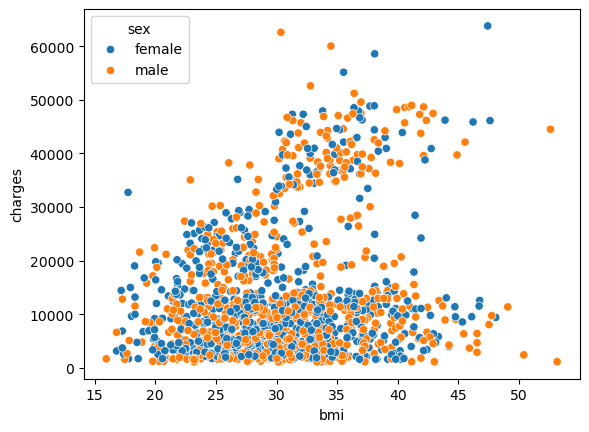

In [15]:
sns.scatterplot( data=med_data, x='bmi', y='charges', hue='sex' )

Analysis : For some people the insurance charges go up with bmi. But it is not true for all.

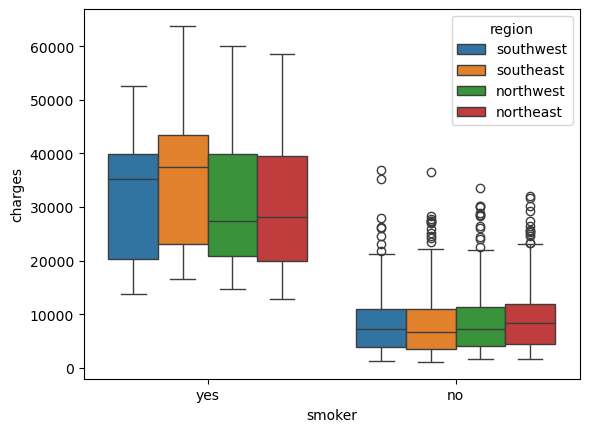

In [17]:
sns.boxplot( data = med_data,  x='smoker', y='charges', hue ='region')
plt.show()

Analysis: This clearly shows for smokers, the insurance charges are higher in all regions.

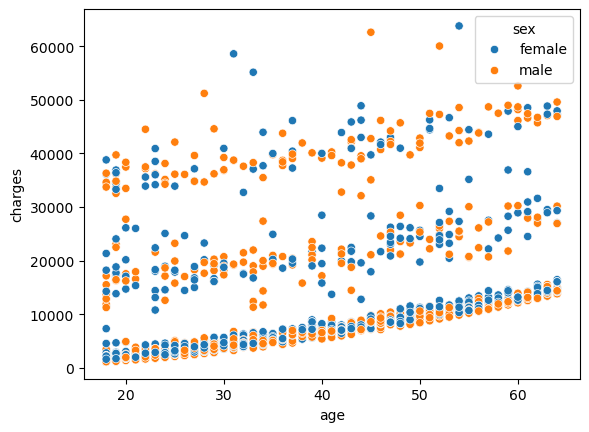

In [19]:
sns.scatterplot( data = med_data,  x='age', y='charges', hue ='sex')
plt.show()

Analysis: This clearly shows as age increases, the insurance charges increases in general. The scatterplot shows 3 different groups of people 
whose charges are in 3 different ranges. These 3 groups have charges in 3 different ranges: 30,000 and up, between 10,000 and 25,000, below 10,000. We have to examine these 3 groups.

In [21]:

group1 = med_data[med_data.charges > 30000.0]
group2 = med_data[(10000.0 < med_data.charges) & (med_data.charges < 25000.0)]
group3 = med_data[med_data.charges < 10000.0]



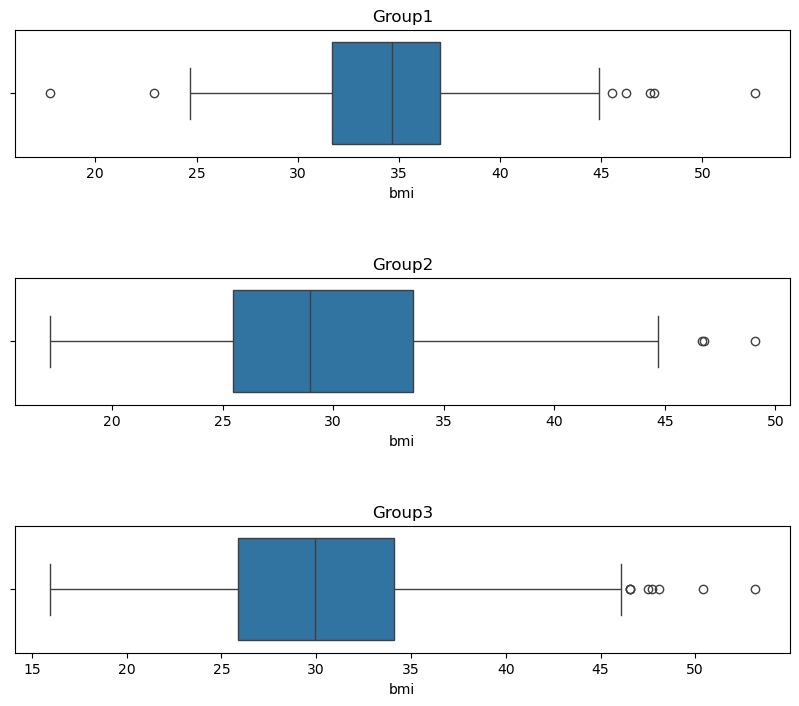

In [43]:
plt.figure(figsize =(10, 7))
ax= plt.subplot(3, 1,1)
sns.boxplot(x='bmi', data=group1)
plt.title('Group1')
plt.subplot(3,1,2)
sns.boxplot(x='bmi', data=group2)
plt.title('Group2')
plt.subplot(3,1,3)
sns.boxplot(x='bmi', data=group3)
plt.title('Group3')
plt.subplots_adjust(top = 1, hspace = .95)

Analysis: The median bmi of the group1 is highest. This is associated with high insurance costs. Comparing group2 and group3
their median bmis are not far apart. It needs more investigation why the group2 has higher cost than group 3.

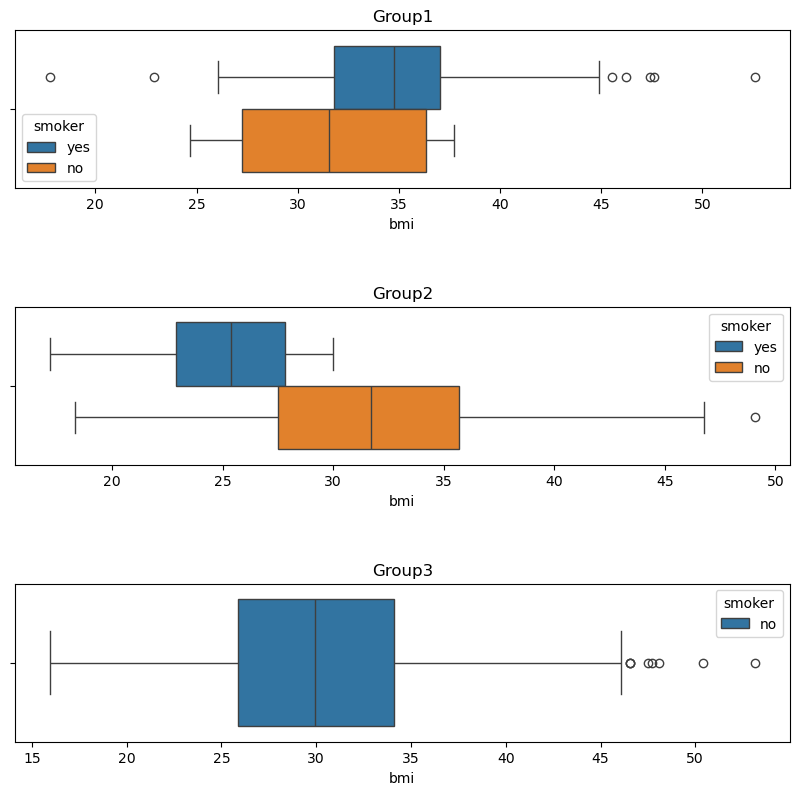

In [47]:
plt.figure(figsize =(10, 8))
ax= plt.subplot(3, 1,1)
sns.boxplot(x='bmi', hue= 'smoker', data=group1)
plt.title('Group1')
plt.subplot(3,1,2)
sns.boxplot(x='bmi', hue= 'smoker', data=group2)
plt.title('Group2')
plt.subplot(3,1,3)
sns.boxplot(x='bmi', hue= 'smoker', data=group3)
plt.title('Group3')
plt.subplots_adjust(top = 1, hspace = .75)

Analysis: Further analysing the smoker status, it is clear that group3 doesn't have smokers while group2 has smokers. Comparing group1 and group2, the former group has smokers with higher bmis compared to the latter group with smokers of lower bmis.

Analysis: The age and bmi does not seem to be related.

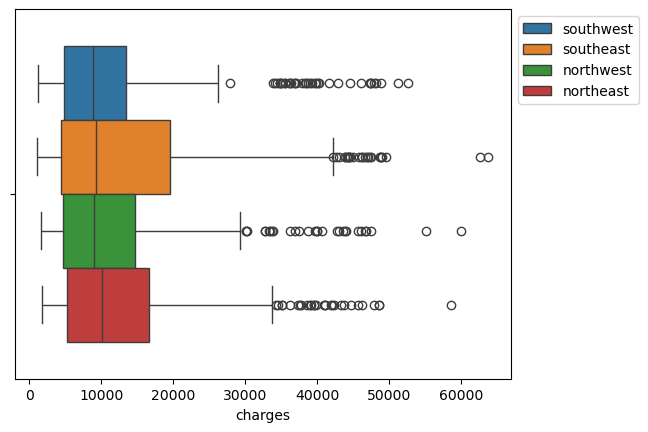

In [61]:
sns.boxplot( data = med_data, x='charges', hue ='region')
plt.legend(bbox_to_anchor =(1,1))
plt.show()

Analysis: The southwest region has the least charges and southeast region has the most charges.